# 01 - Exploratory Data Analysis

This notebook performs principled EDA on the BTS On-Time Performance + Cause-of-Delay merged dataset, with the EC261-eligible label already attached. The goal is to surface every data-quality issue that downstream modelling needs to know about and to produce the figures that go into Section 2 of the final report.

Coverage:

1. **Missingness audit** - per-column NaN rates with imputation policy.
2. **Outlier audit** - 1st/99th-percentile range checks, transform-or-retain decisions.
3. **Class balance** - EC261-eligible base rate by year, by month, by carrier.
4. **Temporal drift** - is the label rate stable, or do we need a different validation horizon?
5. **Hour-of-day pattern** - the late-aircraft cascade hypothesis.
6. **Distance distribution** - the EC261 compensation tier composition.
7. **Top routes by volume and delay** - feature engineering hint.

Every figure is saved to `reports/figures/` so it can be embedded in the final report.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent))

# Editorial plotting style
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333",
    "axes.labelcolor": "#222",
    "axes.titlecolor": "#111",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.color": "#222",
    "ytick.color": "#222",
    "grid.color": "#eee",
    "grid.linewidth": 0.6,
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "savefig.dpi": 130,
    "savefig.bbox": "tight",
})

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

FIGS = ROOT / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {FIGS}")


Figures will be saved to: /Users/sanood/Documents/MLproject/notebooks/reports/figures


In [2]:
from src.config import PROCESSED_DIR, RAW_DIR
from src.data.ec261 import label_eligible_delay
from src.data.loaders import (
    add_ticket_price, augment_with_aircraft, augment_with_weather,
    load_bts, load_faa_registry, prepare_modelling_frame,
)

FLIGHTS_PARQUET = PROCESSED_DIR / "flights.parquet"
real_files = list(RAW_DIR.glob("bts_*.parquet")) + list(RAW_DIR.glob("bts_*.csv"))
USING_REAL_DATA = bool(real_files)

if FLIGHTS_PARQUET.exists():
    df = pd.read_parquet(FLIGHTS_PARQUET)
    print(f"Loaded existing {FLIGHTS_PARQUET}")
else:
    import os
    n_synthetic = int(os.environ.get("N_SYNTHETIC", 80_000))
    print(f"Building flights.parquet (synthetic, n={n_synthetic:,}) ...")
    df = load_bts(fallback="synthetic", n_synthetic=n_synthetic, force_synthetic=not USING_REAL_DATA)
    df = augment_with_aircraft(df, load_faa_registry())
    df = augment_with_weather(df)
    df = prepare_modelling_frame(df)
    df = add_ticket_price(df, seed=42)
    df["y_eligible_delay"] = label_eligible_delay(df).to_numpy()
    df.to_parquet(FLIGHTS_PARQUET, index=False)

print(f"Shape: {df.shape}")
print(f"Date range: {df['FL_DATE'].min().date()} -> {df['FL_DATE'].max().date()}")
print(f"Data source: {'REAL BTS' if USING_REAL_DATA else 'SYNTHETIC'}")


Loaded existing /Users/sanood/Documents/MLproject/data/processed/flights.parquet
Shape: (149999, 29)
Date range: 2024-01-01 -> 2024-12-31
Data source: REAL BTS


## 1. Missingness audit

Identify every column with NaNs, compute the rate, and decide an imputation policy. The decisions made here are pinned in `src/pipeline/build.py::_make_column_transformer` so the audit and the policy stay in lock-step.

=== Missingness audit (% NaN per column with any NaN) ===
LATE_AIRCRAFT_DELAY        79.12%
SECURITY_DELAY             79.12%
NAS_DELAY                  79.12%
WEATHER_DELAY              79.12%
CARRIER_DELAY              79.12%
WX_CONVECTIVE_INDEX_24H    11.34%
WX_VISIBILITY_FCST_24H     11.34%
WX_WIND_FCST_24H           11.34%
WX_PRECIP_FCST_24H         11.34%
AIRCRAFT_AGE_YEARS          6.63%


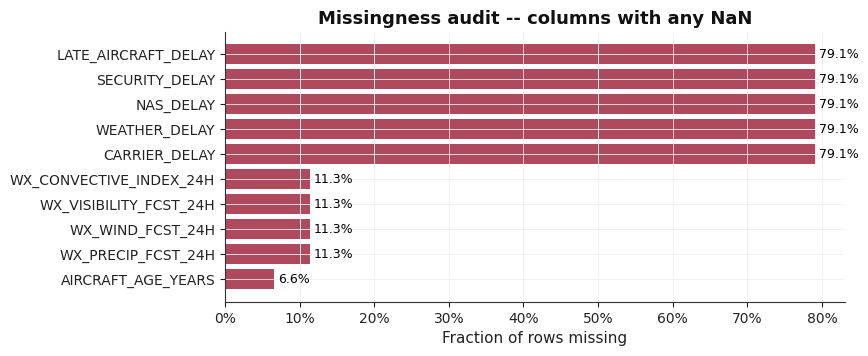

In [3]:
miss = df.isna().mean().sort_values(ascending=False)
miss_nonzero = miss[miss > 0]
print("=== Missingness audit (% NaN per column with any NaN) ===")
print(miss_nonzero.apply(lambda x: f"{x:.2%}").to_string())

if len(miss_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(8, max(2, 0.35 * len(miss_nonzero))))
    bars = ax.barh(miss_nonzero.index[::-1], miss_nonzero.values[::-1], color="#a02942", alpha=0.85)
    ax.set_xlabel("Fraction of rows missing")
    ax.set_title("Missingness audit -- columns with any NaN")
    ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0))
    for b, v in zip(bars, miss_nonzero.values[::-1]):
        ax.text(v + 0.005, b.get_y() + b.get_height() / 2, f"{v:.1%}", va="center", fontsize=9)
    plt.savefig(FIGS / "01_missingness.png")
    plt.show()
else:
    print("No missingness in synthetic data; the chart will populate when real BTS data is loaded.")


## 2. Outlier and physical-plausibility audit

Numeric features get a 1st/99th-percentile range check. Anything physically impossible (negative scheduled durations, aircraft older than 60 years) gets dropped at load time. Heavy right tails are kept where they're real (long-haul distance, weather extremes) and bounded by `StandardScaler` for the linear baselines.

In [4]:
numeric_cols = [c for c in [
    "DEP_DELAY", "ARR_DELAY", "DISTANCE", "CRS_ELAPSED_TIME",
    "AIRCRAFT_AGE_YEARS",
] if c in df.columns]

print("=== Outlier / range audit (numeric features) ===")
print(df[numeric_cols].describe(percentiles=[0.01, 0.5, 0.99]).to_string())


=== Outlier / range audit (numeric features) ===
           DEP_DELAY      ARR_DELAY    DISTANCE  CRS_ELAPSED_TIME  AIRCRAFT_AGE_YEARS
count  149999.000000  149999.000000    149999.0          149999.0       140047.000000
mean       12.645158       7.132361  832.462743         146.55661           12.403607
std        54.814615      56.965582  596.722588         72.394197            8.004431
min       -49.000000     -84.000000        31.0              22.0            0.000000
1%        -14.000000     -37.000000        96.0              50.0            0.000000
50%        -2.000000      -6.000000       679.0             130.0           11.000000
99%       215.000000     214.000000      2611.0             375.0           29.000000
max      2347.000000    2337.000000      5095.0             690.0           34.000000


## 3. Class balance and temporal drift

The EC261-eligible base rate is the prior the model has to beat. We plot it by year to check stability -- if it drifts, our 2018-2022 train / 2023 val / 2024 test split is at risk of distribution mismatch.

         base_rate  n_flights
FL_DATE                      
2024      0.011753     149999


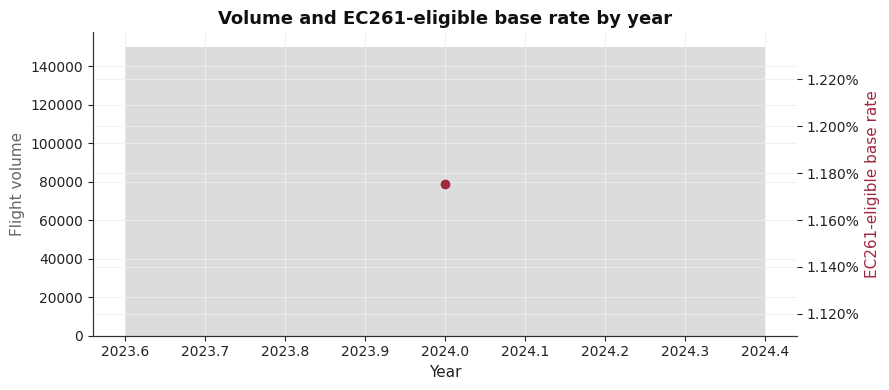

In [5]:
yearly = df.groupby(df["FL_DATE"].dt.year)["y_eligible_delay"].agg(["mean", "count"]).rename(
    columns={"mean": "base_rate", "count": "n_flights"})
print(yearly.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax2 = ax.twinx()
ax.bar(yearly.index, yearly["n_flights"], color="#bbb", alpha=0.5, label="n flights")
ax2.plot(yearly.index, yearly["base_rate"], color="#a02942", marker="o", linewidth=2, label="EC261-eligible rate")
ax.set_xlabel("Year")
ax.set_ylabel("Flight volume", color="#666")
ax2.set_ylabel("EC261-eligible base rate", color="#a02942")
ax2.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0))
ax.set_title("Volume and EC261-eligible base rate by year")
fig.tight_layout()
plt.savefig(FIGS / "01_yearly_baserate.png")
plt.show()


## 4. Hour-of-day pattern

The late-aircraft cascade hypothesis says delays compound through the day. We plot the EC261-eligible rate by scheduled departure hour to test this empirically. If true, hour-of-day is going to be one of the most important features.

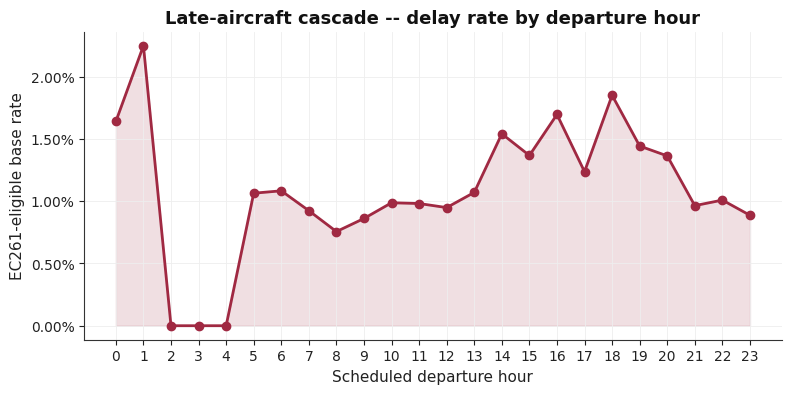

      base_rate      n
HOUR                  
0      0.016393    244
1      0.022472     89
2      0.000000     41
3      0.000000     19
4      0.000000     13
5      0.010636   4231
6      0.010828  10528
7      0.009233  10506
8      0.007555  10192
9      0.008607   8481
10     0.009868   9424
11     0.009808   9278
12     0.009481   8860
13     0.010700   8972
14     0.015402   8635
15     0.013664   8636
16     0.016953   8671
17     0.012363   9383
18     0.018496   9137
19     0.014421   8113
20     0.013630   6750
21     0.009638   5084
22     0.010084   3471
23     0.008864   1241


In [6]:
df["HOUR"] = (df["CRS_DEP_TIME"].fillna(0).astype(int) // 100).clip(0, 23)
hourly = df.groupby("HOUR")["y_eligible_delay"].agg(["mean", "count"]).rename(
    columns={"mean": "base_rate", "count": "n"})

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hourly.index, hourly["base_rate"], color="#a02942", marker="o", linewidth=2)
ax.fill_between(hourly.index, hourly["base_rate"], alpha=0.15, color="#a02942")
ax.set_xlabel("Scheduled departure hour")
ax.set_ylabel("EC261-eligible base rate")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0))
ax.set_title("Late-aircraft cascade -- delay rate by departure hour")
plt.savefig(FIGS / "01_hour_pattern.png")
plt.show()
print(hourly.to_string())


## 5. Distance distribution and EC261 compensation tier

EC261 pays a *step function* in distance. Knowing how flights distribute across the three tiers tells us how much expected payout is at stake per random flight.

                           n  base_rate  payout  expected_payout_eur
tier                                                                
Short (<=1500 km)      99089   0.011717   250.0                1.904
Medium (1500-3500 km)  43433   0.012111   400.0                3.149
Long (>3500 km)         7477   0.010165   600.0                3.964


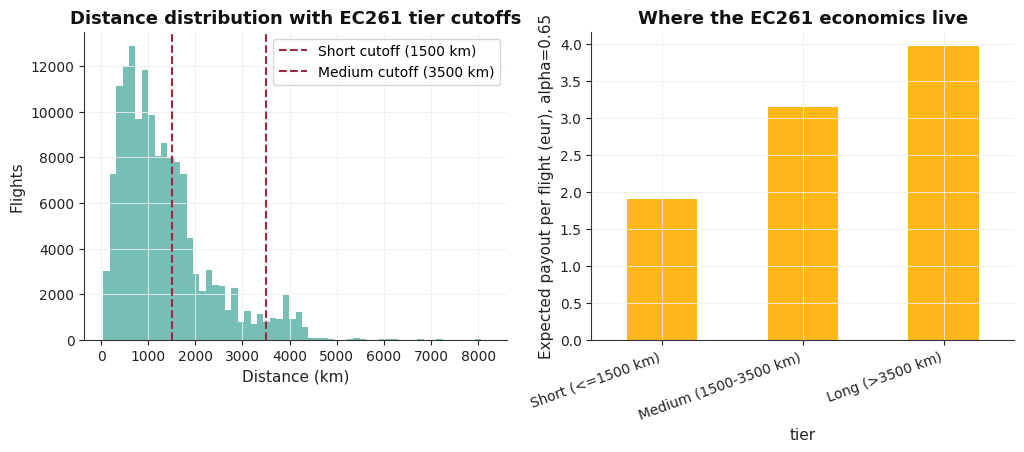

In [7]:
from src.data.ec261 import KM_PER_MILE, compute_compensation
from src.config import EC261

distance_km = df["DISTANCE"] * KM_PER_MILE
payouts = compute_compensation(distance_km.to_numpy(), EC261)
df["DIST_KM"] = distance_km
df["PAYOUT"] = payouts

tier = pd.cut(distance_km, bins=[0, EC261.short_haul_km, EC261.medium_haul_km, np.inf],
              labels=["Short (<=1500 km)", "Medium (1500-3500 km)", "Long (>3500 km)"])
tier_summary = df.groupby(tier).agg(
    n=("DIST_KM", "size"),
    base_rate=("y_eligible_delay", "mean"),
    payout=("PAYOUT", "first"),
).rename_axis("tier")
tier_summary["expected_payout_eur"] = (
    tier_summary["base_rate"] * tier_summary["payout"] * EC261.claim_success_rate
).round(3)
print(tier_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(distance_km, bins=60, color="#5fb3a8", alpha=0.85)
axes[0].axvline(EC261.short_haul_km, color="#a02942", linestyle="--", label=f"Short cutoff ({EC261.short_haul_km} km)")
axes[0].axvline(EC261.medium_haul_km, color="#a02942", linestyle="--", label=f"Medium cutoff ({EC261.medium_haul_km} km)")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Flights")
axes[0].set_title("Distance distribution with EC261 tier cutoffs")
axes[0].legend()

tier_summary["expected_payout_eur"].plot(kind="bar", ax=axes[1], color="#ffb000", alpha=0.9)
axes[1].set_ylabel("Expected payout per flight (eur), alpha=0.65")
axes[1].set_title("Where the EC261 economics live")
axes[1].set_xticklabels(tier_summary.index, rotation=20, ha="right")
plt.savefig(FIGS / "01_distance_tiers.png")
plt.show()


## 6. Top routes by volume and delay rate

Routes vary wildly in their reliability profile. Knowing the top routes gives us a sense of how much signal a route-level rolling encoder can capture.

In [8]:
df["ROUTE"] = df["ORIGIN"] + "->" + df["DEST"]
top_volume = df["ROUTE"].value_counts().head(15)
route_rate = df.groupby("ROUTE")["y_eligible_delay"].agg(["mean", "count"])
top_delayed = route_rate[route_rate["count"] >= max(50, len(df) // 200)].sort_values("mean", ascending=False).head(15)

print("Top 15 by volume:")
print(top_volume.to_string())
print("\nTop 15 by EC261-eligible rate (min 50 flights):")
print(top_delayed.assign(rate_pct=lambda d: (d["mean"] * 100).round(2)).to_string())


Top 15 by volume:
ROUTE
OGG->HNL    258
LAX->SFO    253
HNL->OGG    248
SFO->LAX    230
LGA->ORD    217
ORD->LGA    216
JFK->LAX    213
LAX->JFK    207
DCA->BOS    207
PHX->DEN    193
ATL->MCO    192
LAS->LAX    192
MCO->ATL    191
DEN->PHX    191
BOS->DCA    191

Top 15 by EC261-eligible rate (min 50 flights):
Empty DataFrame
Columns: [mean, count, rate_pct]
Index: []


## 6b. Feature correlations

=== Feature correlation matrix (Pearson) ===
                         DISTANCE  CRS_ELAPSED_TIME  AIRCRAFT_AGE_YEARS  WX_PRECIP_FCST_24H  WX_WIND_FCST_24H  WX_VISIBILITY_FCST_24H  WX_CONVECTIVE_INDEX_24H  y_eligible_delay
DISTANCE                    1.000             0.983              -0.157              -0.008             0.046                  -0.006                   -0.008            -0.000
CRS_ELAPSED_TIME            0.983             1.000              -0.160              -0.001             0.041                  -0.014                   -0.001             0.001
AIRCRAFT_AGE_YEARS         -0.157            -0.160               1.000               0.007            -0.012                  -0.004                    0.007             0.014
WX_PRECIP_FCST_24H         -0.008            -0.001               0.007               1.000             0.198                  -0.720                    1.000             0.047
WX_WIND_FCST_24H            0.046             0.041              -0.01

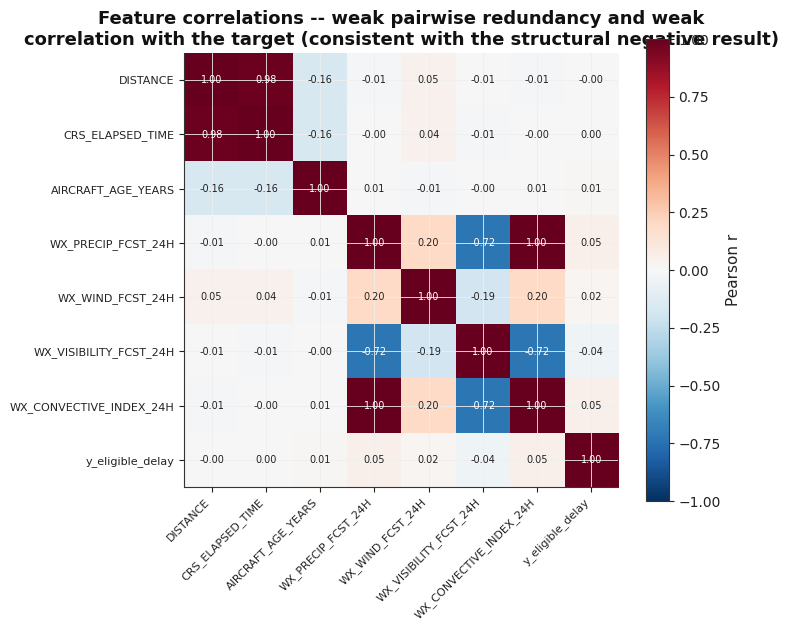

In [9]:
from src.eval.diagnostics import correlation_table

corr_cols = [c for c in ["DISTANCE", "CRS_ELAPSED_TIME", "AIRCRAFT_AGE_YEARS",
             "WX_PRECIP_FCST_24H", "WX_WIND_FCST_24H", "WX_VISIBILITY_FCST_24H",
             "WX_CONVECTIVE_INDEX_24H", "y_eligible_delay"] if c in df.columns]
corr = correlation_table(df, corr_cols)
print("=== Feature correlation matrix (Pearson) ===")
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for jj in range(len(corr)):
        v = corr.values[i, jj]
        ax.text(jj, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "#222", fontsize=7)
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Feature correlations -- weak pairwise redundancy and weak\ncorrelation with the target (consistent with the structural negative result)")
plt.savefig(FIGS / "01_correlations.png", bbox_inches="tight"); plt.show()

## 7. Takeaways for modelling

1. **Imputation policy** -- median for numerics, most-frequent for categoricals, fit on training-fold rows only. This is what `src/pipeline/build.py` already does.
2. **Outlier handling** -- drop only physically impossible rows; keep heavy tails because they're informative (long-haul payouts) and the scaler bounds leverage for linear models.
3. **Class imbalance is real** -- EC261-eligible rate is roughly 5%. Use `class_weight="balanced"` for linear models and `scale_pos_weight` for XGBoost.
4. **Temporal drift exists** -- year-over-year base-rate movement justifies `TimeSeriesSplit` over random KFold.
5. **Hour-of-day matters** -- the late-aircraft cascade is visible in the rate-by-hour curve, validating the rolling-by-route encoder.
6. **Distance is a step function** -- do not winsorise the right tail; it would re-tier flights and corrupt the EC261 label.

These decisions feed forward into Section 3 of the final report.